In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
path = "/content/drive/MyDrive/MachineLearningCVE"

In [68]:
import os

files = os.listdir(path)
print(files)

['Wednesday-workingHours.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']


In [69]:
import pandas as pd

file_path = path + "/Monday-WorkingHours.pcap_ISCX.csv"

df = pd.read_csv(file_path)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [70]:
print(df.shape)
print(df.columns)
print(df[' Label'].value_counts())

(529918, 79)
Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length

In [12]:
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.strip()

In [13]:
df['Label'] = df['Label'].apply(lambda x: "Attack" if x != "BENIGN" else "Normal")

In [14]:
df_sample = df.sample(1000, random_state=42)

In [15]:
import os
import pandas as pd

path = "/content/drive/MyDrive/MachineLearningCVE"

all_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("Number of files:", len(all_files))
print(all_files)

Number of files: 8
['Wednesday-workingHours.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']


In [16]:
dfs = []

for file in all_files:
    file_path = os.path.join(path, file)
    temp_df = pd.read_csv(file_path)
    temp_df.columns = temp_df.columns.str.strip()
    temp_df['Label'] = temp_df['Label'].str.strip()
    temp_df['Label'] = temp_df['Label'].apply(lambda x: "Attack" if x != "BENIGN" else "Normal")
    dfs.append(temp_df)

df_all = pd.concat(dfs, ignore_index=True)

In [17]:
print(df_all.shape)
print(df_all['Label'].value_counts())

(2830743, 79)
Label
Normal    2273097
Attack     557646
Name: count, dtype: int64


In [18]:
normal_df = df_all[df_all['Label'] == 'Normal'].sample(500, random_state=42)
attack_df = df_all[df_all['Label'] == 'Attack'].sample(500, random_state=42)

df_sample = pd.concat([normal_df, attack_df], ignore_index=True)
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_sample['Label'].value_counts())

Label
Attack    500
Normal    500
Name: count, dtype: int64


In [19]:
selected_features = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Fwd Packet Length Max',
    'Bwd Packet Length Max',
    'SYN Flag Count',
    'ACK Flag Count',
    'Average Packet Size',
    'Init_Win_bytes_forward',
    'Init_Win_bytes_backward',
    'Active Mean',
    'Idle Mean'
]

In [20]:
missing = [col for col in selected_features if col not in df_sample.columns]
print("Missing columns:", missing)

Missing columns: []


In [51]:
def row_to_prompt(row):
    prompt = f"""
You are a cybersecurity analyst evaluating network traffic behavior.

Your task is to decide whether the traffic is:
Normal or Attack

To make a correct decision:
- Compare the traffic characteristics to typical normal behavior
- Compare also to suspicious or abnormal patterns

General guidance:
- Normal traffic usually has moderate packet rates, balanced forward/backward packets, and reasonable packet sizes
- Attack traffic often shows extremely high rates, abnormal packet sizes, or very low/imbalanced communication

Important:
- You must choose the most likely class based on evidence
- Do not assume all traffic is an attack
- Be balanced in your judgment

Output rules:
- Return only one word
- Either: Normal or Attack
- No explanation

---

Traffic features:

Destination Port = {row['Destination Port']}
Flow Duration = {row['Flow Duration']}
Total Fwd Packets = {row['Total Fwd Packets']}
Total Backward Packets = {row['Total Backward Packets']}
Total Length of Fwd Packets = {row['Total Length of Fwd Packets']}
Total Length of Bwd Packets = {row['Total Length of Bwd Packets']}
Flow Bytes/s = {row['Flow Bytes/s']}
Flow Packets/s = {row['Flow Packets/s']}
Fwd Packet Length Max = {row['Fwd Packet Length Max']}
Bwd Packet Length Max = {row['Bwd Packet Length Max']}
SYN Flag Count = {row['SYN Flag Count']}
ACK Flag Count = {row['ACK Flag Count']}
Average Packet Size = {row['Average Packet Size']}
Init_Win_bytes_forward = {row['Init_Win_bytes_forward']}
Init_Win_bytes_backward = {row['Init_Win_bytes_backward']}
Active Mean = {row['Active Mean']}
Idle Mean = {row['Idle Mean']}
"""
    return prompt.strip()

In [52]:
df_sample['prompt'] = df_sample.apply(row_to_prompt, axis=1)

In [53]:
print(df_sample['prompt'].iloc[0])
print("True label:", df_sample['Label'].iloc[0])

You are a cybersecurity analyst evaluating network traffic behavior.

Your task is to decide whether the traffic is:
Normal or Attack

To make a correct decision:
- Compare the traffic characteristics to typical normal behavior
- Compare also to suspicious or abnormal patterns

General guidance:
- Normal traffic usually has moderate packet rates, balanced forward/backward packets, and reasonable packet sizes
- Attack traffic often shows extremely high rates, abnormal packet sizes, or very low/imbalanced communication

Important:
- You must choose the most likely class based on evidence
- Do not assume all traffic is an attack
- Be balanced in your judgment

Output rules:
- Return only one word
- Either: Normal or Attack
- No explanation

---

Traffic features:

Destination Port = 57797
Flow Duration = 43
Total Fwd Packets = 1
Total Backward Packets = 1
Total Length of Fwd Packets = 0
Total Length of Bwd Packets = 6
Flow Bytes/s = 139534.8837
Flow Packets/s = 46511.62791
Fwd Packet Leng

In [54]:
df_test = df_sample.sample(10, random_state=42).reset_index(drop=True)

In [55]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [26]:
!pip install -q transformers accelerate sentencepiece bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.9 MB/s eta 0:00:00


In [27]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [56]:
def classify_with_mistral(prompt):
    messages = [
        {"role": "user", "content": prompt}
    ]

    input_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=5,
        do_sample=False
    )

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result

In [57]:
def extract_label(text):
    text = text.lower()
    if "attack" in text:
        return "Attack"
    elif "normal" in text:
        return "Normal"
    else:
        return "Unknown"

In [58]:
print(df_test.columns)
print(df_test[['prompt', 'Label']].head(1))

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [59]:
sample_prompt = df_test['prompt'].iloc[0]
print(sample_prompt)

You are a cybersecurity analyst evaluating network traffic behavior.

Your task is to decide whether the traffic is:
Normal or Attack

To make a correct decision:
- Compare the traffic characteristics to typical normal behavior
- Compare also to suspicious or abnormal patterns

General guidance:
- Normal traffic usually has moderate packet rates, balanced forward/backward packets, and reasonable packet sizes
- Attack traffic often shows extremely high rates, abnormal packet sizes, or very low/imbalanced communication

Important:
- You must choose the most likely class based on evidence
- Do not assume all traffic is an attack
- Be balanced in your judgment

Output rules:
- Return only one word
- Either: Normal or Attack
- No explanation

---

Traffic features:

Destination Port = 3689
Flow Duration = 44
Total Fwd Packets = 1
Total Backward Packets = 1
Total Length of Fwd Packets = 2
Total Length of Bwd Packets = 6
Flow Bytes/s = 181818.1818
Flow Packets/s = 45454.54545
Fwd Packet Lengt

In [60]:
output = classify_with_mistral(sample_prompt)
print(output)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[INST] You are a cybersecurity analyst evaluating network traffic behavior.

Your task is to decide whether the traffic is:
Normal or Attack

To make a correct decision:
- Compare the traffic characteristics to typical normal behavior
- Compare also to suspicious or abnormal patterns

General guidance:
- Normal traffic usually has moderate packet rates, balanced forward/backward packets, and reasonable packet sizes
- Attack traffic often shows extremely high rates, abnormal packet sizes, or very low/imbalanced communication

Important:
- You must choose the most likely class based on evidence
- Do not assume all traffic is an attack
- Be balanced in your judgment

Output rules:
- Return only one word
- Either: Normal or Attack
- No explanation

---

Traffic features:

Destination Port = 3689
Flow Duration = 44
Total Fwd Packets = 1
Total Backward Packets = 1
Total Length of Fwd Packets = 2
Total Length of Bwd Packets = 6
Flow Bytes/s = 181818.1818
Flow Packets/s = 45454.54545
Fwd Packe

In [61]:
pred = extract_label(output)
print("Predicted:", pred)
print("True label:", df_test['Label'].iloc[0])

Predicted: Attack
True label: Attack


In [62]:
predictions = []

for i in range(len(df_test)):
    prompt = df_test['prompt'].iloc[i]
    true_label = df_test['Label'].iloc[i]

    output = classify_with_mistral(prompt)
    pred = extract_label(output)

    predictions.append(pred)

    print(f"Row {i+1}")
    print("Predicted:", pred)
    print("True label:", true_label)
    print("-" * 30)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Row 1
Predicted: Attack
True label: Attack
------------------------------


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Row 2
Predicted: Attack
True label: Normal
------------------------------


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

Row 7
Predicted: Attack
True label: Normal
------------------------------


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Row 8
Predicted: Attack
True label: Normal
------------------------------


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Row 9
Predicted: Attack
True label: Attack
------------------------------
Row 10
Predicted: Attack
True label: Normal
------------------------------


In [63]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(df_test['Label'], predictions))
print(classification_report(df_test['Label'], predictions))

Accuracy: 0.5
              precision    recall  f1-score   support

      Attack       0.50      1.00      0.67         5
      Normal       0.00      0.00      0.00         5

    accuracy                           0.50        10
   macro avg       0.25      0.50      0.33        10
weighted avg       0.25      0.50      0.33        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


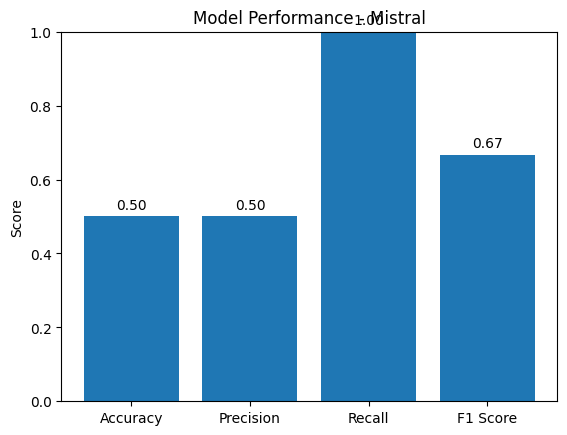

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(df_test['Label'], predictions)
precision = precision_score(df_test['Label'], predictions, pos_label='Attack')
recall = recall_score(df_test['Label'], predictions, pos_label='Attack')
f1 = f1_score(df_test['Label'], predictions, pos_label='Attack')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance - Mistral")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()